Import

In [3]:
import pandas as pd
import os
import plotly.express as px
import calendar
from mlxtend.frequent_patterns import apriori, association_rules
import matplotlib.pyplot as plt

In [4]:
#vérification du chemin des données
path=os.path.expanduser("~/data.csv")
print(os.path.isfile(os.path.expanduser("~/data.csv")))

True


In [5]:
#Chargement des données csv
data=pd.read_csv(os.path.expanduser("~/data.csv"),sep=",",encoding_errors="ignore")

In [6]:
data.head(10)

,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country
0,536365,85123A,WHITE HANGING HEART T-LIGHT HOLDER,6,12/1/2010 8:26,2.55,17850.0,United Kingdom
1,536365,71053,WHITE METAL LANTERN,6,12/1/2010 8:26,3.39,17850.0,United Kingdom
2,536365,84406B,CREAM CUPID HEARTS COAT HANGER,8,12/1/2010 8:26,2.75,17850.0,United Kingdom
3,536365,84029G,KNITTED UNION FLAG HOT WATER BOTTLE,6,12/1/2010 8:26,3.39,17850.0,United Kingdom
4,536365,84029E,RED WOOLLY HOTTIE WHITE HEART.,6,12/1/2010 8:26,3.39,17850.0,United Kingdom
5,536365,22752,SET 7 BABUSHKA NESTING BOXES,2,12/1/2010 8:26,7.65,17850.0,United Kingdom
6,536365,21730,GLASS STAR FROSTED T-LIGHT HOLDER,6,12/1/2010 8:26,4.25,17850.0,United Kingdom
7,536366,22633,HAND WARMER UNION JACK,6,12/1/2010 8:28,1.85,17850.0,United Kingdom
8,536366,22632,HAND WARMER RED POLKA DOT,6,12/1/2010 8:28,1.85,17850.0,United Kingdom
9,536367,84879,ASSORTED COLOUR BIRD ORNAMENT,32,12/1/2010 8:34,1.69,13047.0,United Kingdom


In [7]:
#Analyse du format des données
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 541909 entries, 0 to 541908
Data columns (total 8 columns):
 #   Column       Non-Null Count   Dtype  
---  ------       --------------   -----  
 0   InvoiceNo    541909 non-null  object 
 1   StockCode    541909 non-null  object 
 2   Description  540455 non-null  object 
 3   Quantity     541909 non-null  int64  
 4   InvoiceDate  541909 non-null  object 
 5   UnitPrice    541909 non-null  float64
 6   CustomerID   406829 non-null  float64
 7   Country      541909 non-null  object 
dtypes: float64(2), int64(1), object(5)
memory usage: 33.1+ MB


In [8]:
#vérification des valeurs manquantes
data.isna().sum()

InvoiceNo           0
StockCode           0
Description      1454
Quantity            0
InvoiceDate         0
UnitPrice           0
CustomerID     135080
Country             0
dtype: int64

In [9]:
Customer_NaN=data[data["CustomerID"].isna()]

In [10]:
Customer_NaN.head(30)

,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country
622,536414,22139,NaN,56,12/1/2010 11:52,0.00,NaN,United Kingdom
1443,536544,21773,DECORATIVE ROSE BATHROOM BOTTLE,1,12/1/2010 14:32,2.51,NaN,United Kingdom
1444,536544,21774,DECORATIVE CATS BATHROOM BOTTLE,2,12/1/2010 14:32,2.51,NaN,United Kingdom
1445,536544,21786,POLKADOT RAIN HAT,4,12/1/2010 14:32,0.85,NaN,United Kingdom
1446,536544,21787,RAIN PONCHO RETROSPOT,2,12/1/2010 14:32,1.66,NaN,United Kingdom
1447,536544,21790,VINTAGE SNAP CARDS,9,12/1/2010 14:32,1.66,NaN,United Kingdom
1448,536544,21791,VINTAGE HEADS AND TAILS CARD GAME,2,12/1/2010 14:32,2.51,NaN,United Kingdom
1449,536544,21801,CHRISTMAS TREE DECORATION WITH BELL,10,12/1/2010 14:32,0.43,NaN,United Kingdom
1450,536544,21802,CHRISTMAS TREE HEART DECORATION,9,12/1/2010 14:32,0.43,NaN,United Kingdom
1451,536544,21803,CHRISTMAS TREE STAR DECORATION,11,12/1/2010 14:32,0.43,NaN,United Kingdom


In [10]:
Description_NaN=data[data["Description"].isna()]

In [11]:
Description_NaN.head(10)

,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country
622,536414,22139,NaN,56,12/1/2010 11:52,0.0,NaN,United Kingdom
1970,536545,21134,NaN,1,12/1/2010 14:32,0.0,NaN,United Kingdom
1971,536546,22145,NaN,1,12/1/2010 14:33,0.0,NaN,United Kingdom
1972,536547,37509,NaN,1,12/1/2010 14:33,0.0,NaN,United Kingdom
1987,536549,85226A,NaN,1,12/1/2010 14:34,0.0,NaN,United Kingdom
1988,536550,85044,NaN,1,12/1/2010 14:34,0.0,NaN,United Kingdom
2024,536552,20950,NaN,1,12/1/2010 14:34,0.0,NaN,United Kingdom
2025,536553,37461,NaN,3,12/1/2010 14:35,0.0,NaN,United Kingdom
2026,536554,84670,NaN,23,12/1/2010 14:35,0.0,NaN,United Kingdom
2406,536589,21777,NaN,-10,12/1/2010 16:50,0.0,NaN,United Kingdom


In [11]:
#traitement des valeurs manquantes
data=data[data["Description"].notna()]
data=data[data["UnitPrice"]!=0.0]

In [12]:
data["Price"]=data["Quantity"]*data["UnitPrice"]

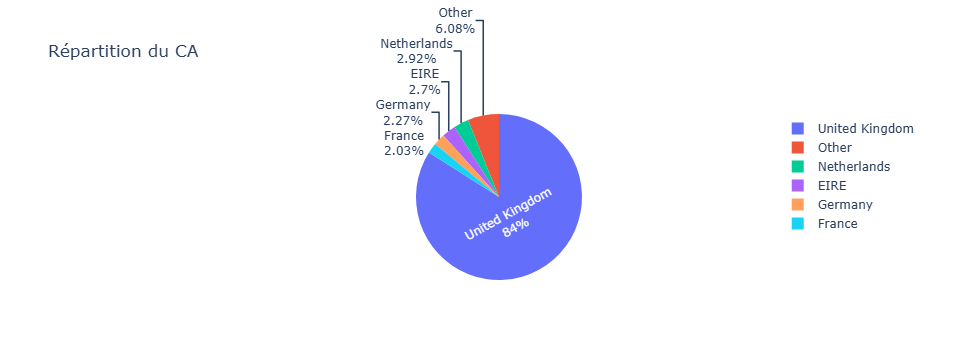

In [13]:
# CA par pays
CA_pays = data.groupby("Country")["Price"].sum().reset_index()

# Pourcentage
CA_pays["Pourcentage"] = 100 * CA_pays["Price"] / CA_pays["Price"].sum()

# Pays avec plus de 2%
CA_major = CA_pays[CA_pays["Pourcentage"] > 2].copy()

# Somme de ceux ≤ 2%
autre_value = CA_pays[CA_pays["Pourcentage"] <= 2]["Price"].sum()
autre_pct = CA_pays[CA_pays["Pourcentage"] <= 2]["Pourcentage"].sum()
# Ajouter une ligne pour "Other"
CA_major.loc[len(CA_major)] = ["Other", autre_value, autre_pct]

fig_ca_pays = px.pie(
    CA_major,
    names="Country",
    values="Pourcentage",   # ou "Price"
    title="Répartition du CA"
)

fig_ca_pays.update_traces(textinfo="label+percent")
fig_ca_pays.show()



In [14]:
#panier total des clients

panier_total=data.groupby("CustomerID")["Price"].sum().reset_index()


In [15]:
panier_total

,CustomerID,Price
0,12346.0,0.00
1,12347.0,4310.00
2,12348.0,1797.24
3,12349.0,1757.55
4,12350.0,334.40
...,...,...
4366,18280.0,180.60
4367,18281.0,80.82
4368,18282.0,176.60
4369,18283.0,2094.88


In [21]:
len(panier_total)

4371

In [16]:
#number of transactions by customer 
trans_per_customer=pd.DataFrame(data["CustomerID"].value_counts())

In [17]:
len(trans_per_customer)

4371

In [18]:
trans_per_customer=trans_per_customer.rename(columns={"count" : "NbAchat"})

In [19]:
data_customer=pd.merge(trans_per_customer,panier_total, on="CustomerID",how="inner") 

In [21]:
#détermination du prix du panier moyen
data_customer["Panier_moyen_client"]=data_customer["Price"]/data_customer["NbAchat"]

In [22]:
data_customer.head(10)

,CustomerID,NbAchat,Price,Panier_moyen_client
0,17841.0,7983,40340.78,5.053336
1,14911.0,5901,132572.62,22.466128
2,14096.0,5128,57120.91,11.139023
3,12748.0,4641,29072.10,6.264189
4,14606.0,2782,11713.85,4.210586
5,15311.0,2491,59419.34,23.853609
6,14646.0,2081,279489.02,134.305151
7,13089.0,1857,57385.88,30.902466
8,13263.0,1677,7454.07,4.444884
9,14298.0,1640,50862.44,31.013683


In [27]:
# CA par facture
CA_par_facture = data.groupby("InvoiceNo")["Price"].sum()

# Panier moyen global
Panier_moyen_value = CA_par_facture.mean()

#on a déterminé le prix moyen par achat et le panier moyen par facture

In [26]:
CA_par_facture.head(10)

InvoiceNo
536365    139.12
536366     22.20
536367    278.73
536368     70.05
536369     17.85
536370    855.86
536371    204.00
536372     22.20
536373    259.86
536374    350.40
Name: Price, dtype: float64

Analyse RFM (Recency,Frequency,Monetary)

Recency

In [28]:
#après conversion de la colonne au format datetime
data["InvoiceDate"]=pd.to_datetime(data["InvoiceDate"])
# Dernière date d'achat par client
last_purchase = data.groupby("CustomerID")["InvoiceDate"].max().reset_index()
last_purchase.columns = ["CustomerID", "LastPurchaseDate"]

In [29]:
# Date de référence = dernière date du dataset
reference_date = data["InvoiceDate"].max()

# Temps écoulé en jours depuis le dernier achat
last_purchase["DaysSinceLastPurchase"] = (reference_date - last_purchase["LastPurchaseDate"]).dt.days


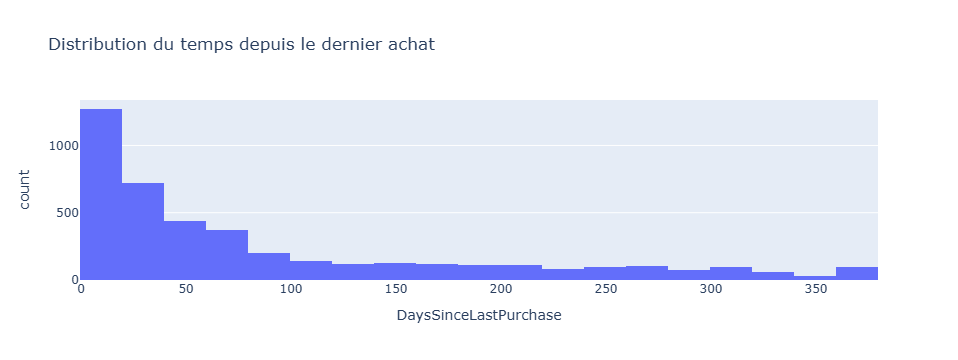

In [31]:
fig_last_purchase = px.histogram(
    last_purchase,
    x="DaysSinceLastPurchase",
    nbins=30,
    title="Distribution du temps depuis le dernier achat"
)
fig_last_purchase.show()


In [32]:
#on définit la date de dernier achat dans les catégories suivantes selon s'il est récent ou non
last_purchase["RecencyCategory"] = pd.qcut(
    last_purchase["DaysSinceLastPurchase"], 
    4, 
    labels=["Très récent", "Récent", "Ancien", "Très ancien"]
)

# estimation du nombre de jours pour appartenir à chaque catégorie
pd.qcut(
    last_purchase["DaysSinceLastPurchase"],
    4
).unique()




[(142.0, 373.0], (-0.001, 16.0], (49.0, 142.0], (16.0, 49.0]]
Categories (4, interval[float64, right]): [(-0.001, 16.0] < (16.0, 49.0] < (49.0, 142.0] < (142.0, 373.0]]

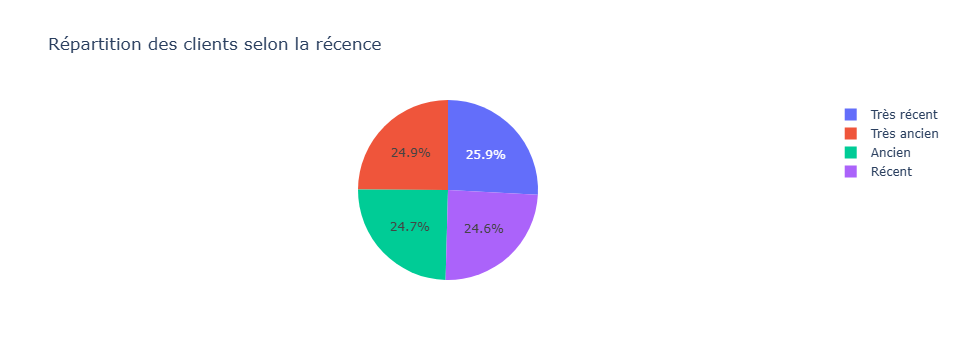

In [33]:
fig = px.pie(
    last_purchase,
    names="RecencyCategory",
    title="Répartition des clients selon la récence"
)
fig.show()


Frequency

In [34]:
#Nombre de factures par clients, nombre d'articles achetés

nb_articles_achetés=data.groupby("CustomerID")["Quantity"].sum().reset_index()
factures=data["InvoiceNo"].value_counts()




In [35]:
factures.head(10)

InvoiceNo
573585    1114
581219     749
581492     731
580729     721
558475     705
579777     687
581217     676
537434     675
580730     662
538071     651
Name: count, dtype: int64

In [38]:
pd.qcut(
    nb_articles_achetés["Quantity"],
    4,
).unique()
#renvoie les quantités pour appartenir à chacune des 4 catégories

[(-303.001, 153.0], (962.0, 196143.0], (365.0, 962.0], (153.0, 365.0]]
Categories (4, interval[float64, right]): [(-303.001, 153.0] < (153.0, 365.0] < (365.0, 962.0] < (962.0, 196143.0]]

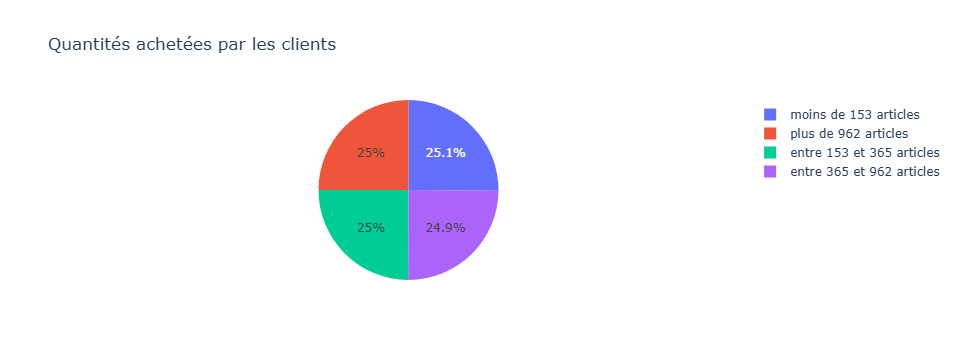

In [40]:
repartitions_ventes=pd.qcut(
    nb_articles_achetés["Quantity"],
    4,
    labels=["moins de 153 articles", "entre 153 et 365 articles", "entre 365 et 962 articles", "plus de 962 articles"]
)

fig_repartitions_ventes=px.pie(
    repartitions_ventes,
    names="Quantity",
    title="Quantités achetées par les clients"
)

fig_repartitions_ventes.show()

In [41]:
# Articles Retournés par les clients
data_retours=data[data["Quantity"] <= 0]

In [42]:
len(data_retours)

9288

In [43]:
#pourcentage de retour
pourcentage_retour=100*len(data_retours)/len(data)
print(pourcentage_retour,"%")

1.7219323907941133 %


In [45]:
len(data["Description"].value_counts())
#nombre d'articles

4040

Analyse de la temporalité

In [46]:
#conversion format datetime
data["InvoiceDate"]=pd.to_datetime(data["InvoiceDate"])
data["Year"]=data["InvoiceDate"].dt.year
data["Month"]=data["InvoiceDate"].dt.month
data["Day"]=data["InvoiceDate"].dt.day
data["Week"] = data["InvoiceDate"].dt.isocalendar().week
data["DayOfWeek"] = data["InvoiceDate"].dt.day_name()
data["Hour"] = data["InvoiceDate"].dt.hour

In [47]:
data["MonthName"] = data["InvoiceDate"].dt.month_name
data["MonthName"] = data["Month"].apply(lambda x: calendar.month_name[x])


In [50]:
#CA par mois
ca_mois = data.groupby(["Month", "MonthName"])["Price"].sum().reset_index()


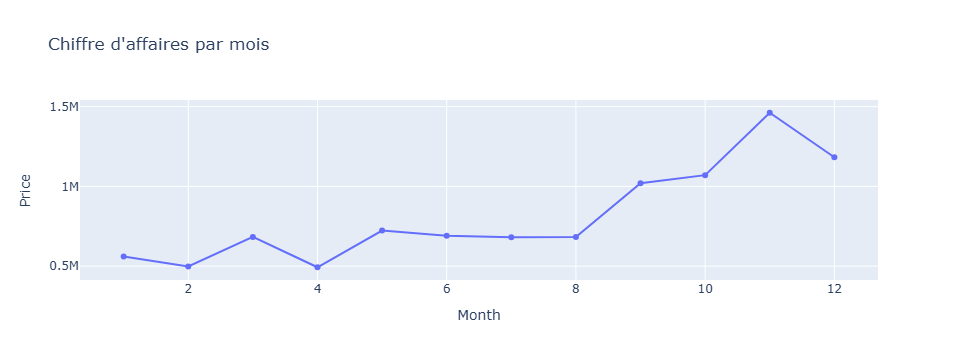

In [53]:
fig_month = px.line(
    ca_mois,
    x="Month",
    y="Price",
    markers=True,
    title="Chiffre d'affaires par mois"
)

fig_month.show()


Le chiffre d'affaire augmente en fin d'année et ne présente pas de saisonalité mensuelle

In [62]:
ca_jour_semaine = data.groupby("DayOfWeek")["Price"].sum().reindex(
    ["Sunday","Monday", "Tuesday", "Wednesday", "Thursday", "Friday", "Saturday"]
).reset_index()


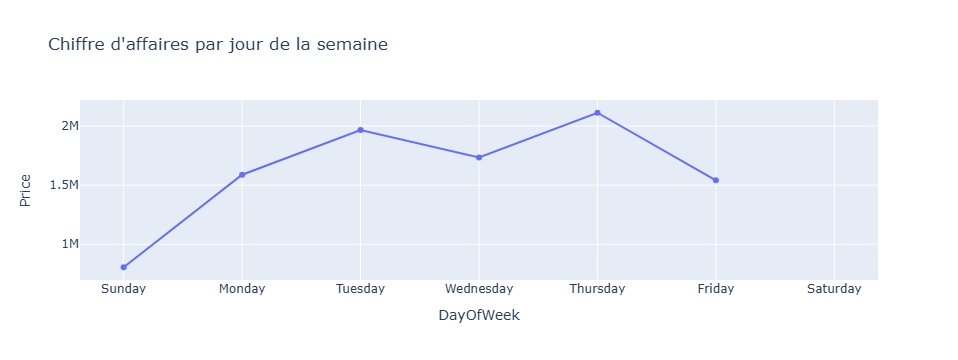

In [63]:
fig_dayofweek = px.line(
    ca_jour_semaine,
    x="DayOfWeek",
    y="Price",
    markers=True,
    title="Chiffre d'affaires par jour de la semaine"
)

fig_dayofweek.show()


Magasin fermé le samedi

Analyse des produits

In [64]:
meilleurs_produits=data.groupby(["StockCode","Description"])[["Price","Quantity"]].sum().reset_index().sort_values(by="Price",ascending=False)

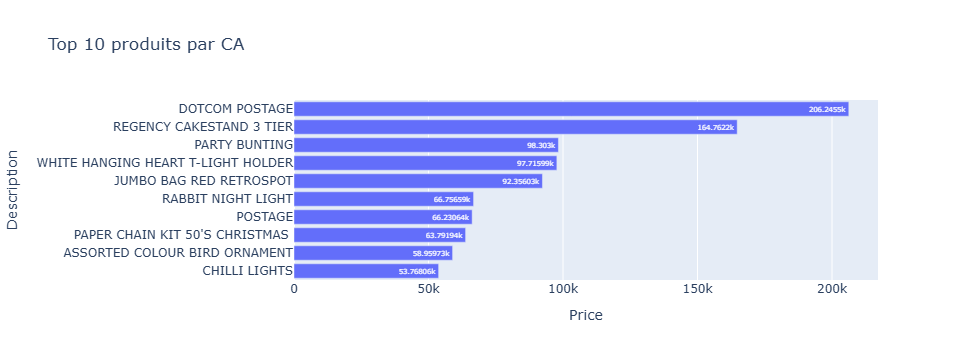

In [66]:
#Analyse des produits qui ont fait le plus de ventes
fig_produit = px.bar(
    meilleurs_produits.head(10),
    x="Price",
    y="Description",
    orientation="h",
    title="Top 10 produits par CA",
    text_auto=True
)

fig_produit.update_layout(yaxis={"categoryorder": "total ascending"})  
fig_produit.show()


In [67]:
#Analyse de la composition des panniers

basket = (
    data.groupby(['InvoiceNo', 'Description'])['Quantity']
        .sum()
        .unstack()
        .fillna(0)
)

# Convertir en binaire : produit acheté = 1
basket = basket.applymap(lambda x: 1 if x > 0 else 0)


C:\Users\emeri\AppData\Local\Temp\ipykernel_11380\622954113.py:11: FutureWarning:

DataFrame.applymap has been deprecated. Use DataFrame.map instead.



In [68]:
#Analyse des produits souvent achetés ensemble par règle d'association
frequent_items = apriori(basket, min_support=0.02, use_colnames=True)

# Règles d'association
rules = association_rules(frequent_items, metric="lift", min_threshold=1)

rules.sort_values(by="lift", ascending=False).head(20)


C:\Users\emeri\anaconda3\envs\data_analysis_env\lib\site-packages\mlxtend\frequent_patterns\fpcommon.py:161: DeprecationWarning:

DataFrames with non-bool types result in worse computationalperformance and their support might be discontinued in the future.Please use a DataFrame with bool type



,antecedents,consequents,antecedent support,consequent support,support,confidence,lift,representativity,leverage,conviction,zhangs_metric,jaccard,certainty,kulczynski
86,"(GREEN REGENCY TEACUP AND SAUCER, ROSES REGENC...",(PINK REGENCY TEACUP AND SAUCER),0.032230,0.032146,0.022733,0.705346,21.942238,1.0,0.021697,3.284710,0.986211,0.545913,0.695559,0.706268
91,(PINK REGENCY TEACUP AND SAUCER),"(GREEN REGENCY TEACUP AND SAUCER, ROSES REGENC...",0.032146,0.032230,0.022733,0.707190,21.942238,1.0,0.021697,3.305109,0.986125,0.545913,0.697438,0.706268
90,(GREEN REGENCY TEACUP AND SAUCER),"(PINK REGENCY TEACUP AND SAUCER, ROSES REGENCY...",0.042567,0.025128,0.022733,0.534057,21.253335,1.0,0.021663,2.092257,0.995316,0.505607,0.522047,0.719370
87,"(PINK REGENCY TEACUP AND SAUCER, ROSES REGENCY...",(GREEN REGENCY TEACUP AND SAUCER),0.025128,0.042567,0.022733,0.904682,21.253335,1.0,0.021663,10.044652,0.977512,0.505607,0.900445,0.719370
13,(PINK REGENCY TEACUP AND SAUCER),(GREEN REGENCY TEACUP AND SAUCER),0.032146,0.042567,0.026557,0.826144,19.408263,1.0,0.025189,5.507042,0.979977,0.551483,0.818414,0.725017
12,(GREEN REGENCY TEACUP AND SAUCER),(PINK REGENCY TEACUP AND SAUCER),0.042567,0.032146,0.026557,0.623889,19.408263,1.0,0.025189,2.573324,0.990644,0.551483,0.611398,0.725017
89,(ROSES REGENCY TEACUP AND SAUCER ),"(GREEN REGENCY TEACUP AND SAUCER, PINK REGENCY...",0.044752,0.026557,0.022733,0.507981,19.128065,1.0,0.021545,1.978467,0.992120,0.467993,0.494558,0.681997
88,"(GREEN REGENCY TEACUP AND SAUCER, PINK REGENCY...",(ROSES REGENCY TEACUP AND SAUCER ),0.026557,0.044752,0.022733,0.856013,19.128065,1.0,0.021545,6.634252,0.973576,0.467993,0.849267,0.681997
11,(GARDENERS KNEELING PAD CUP OF TEA ),(GARDENERS KNEELING PAD KEEP CALM ),0.031851,0.038365,0.022943,0.720317,18.775570,1.0,0.021721,3.438300,0.977886,0.485333,0.709159,0.659173
10,(GARDENERS KNEELING PAD KEEP CALM ),(GARDENERS KNEELING PAD CUP OF TEA ),0.038365,0.031851,0.022943,0.598028,18.775570,1.0,0.021721,2.408500,0.984510,0.485333,0.584804,0.659173


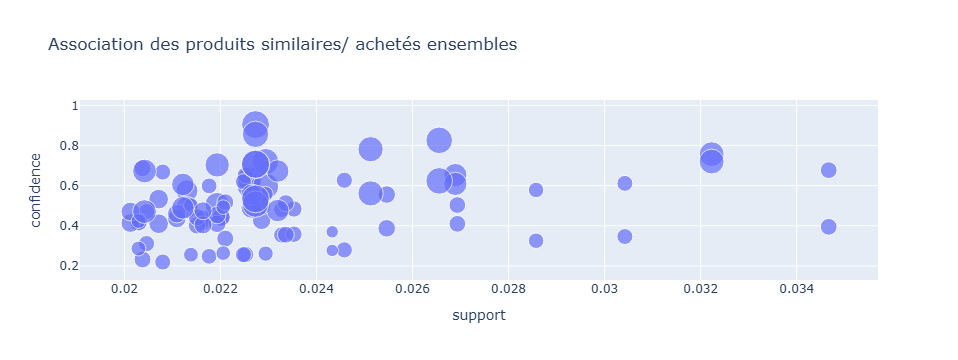

In [70]:
# Convertir les frozenset en string pour Plotly
rules["antecedents_str"] = rules["antecedents"].apply(lambda x: ", ".join(list(x)))
rules["consequents_str"] = rules["consequents"].apply(lambda x: ", ".join(list(x)))


fig_basket = px.scatter(
    rules,
    x="support",
    y="confidence",
    size="lift",
    hover_data=["antecedents_str", "consequents_str"],
    title="Association des produits similaires/ achetés ensembles"
)

fig_basket.show()


In [71]:
#produit en croissance/decroissance 

data["YearMonth"] = data["InvoiceDate"].dt.to_period("M")

ca_prod_mensuel = data.groupby(["StockCode", "Description", "YearMonth"])["Price"].sum().reset_index()

ca_prod_mensuel["Growth"] = ca_prod_mensuel.groupby("StockCode")["Price"].pct_change()




In [72]:
top_croissance = (
    ca_prod_mensuel.sort_values(by="Growth", ascending=False)
                   .dropna()
                   .head(20)
)
top_decroissance = (
    ca_prod_mensuel.sort_values(by="Growth", ascending=True)
                   .dropna()
                   .head(20)
)


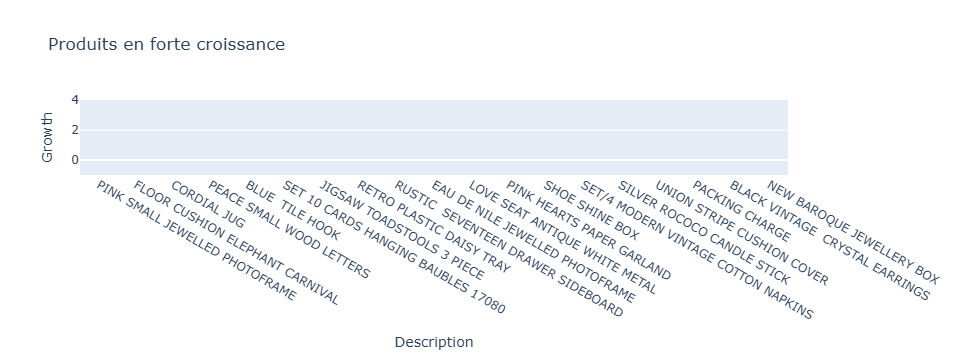

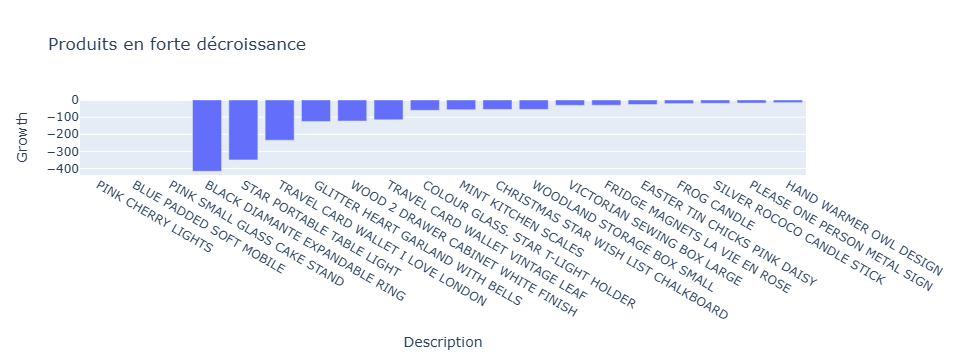

In [73]:
px.bar(top_croissance, x="Description", y="Growth", title="Produits en forte croissance").show()
px.bar(top_decroissance, x="Description", y="Growth", title="Produits en forte décroissance").show()


Analyse du churn (départ d'un client chez un concurrent) et de la fidélité cliente

In [74]:
#Analyse comportement des clients : fidélité, gros paniers peu fréquents, petits paniers fréquents, churn


# Nombre d'achats par client (nombre de factures distinctes)
achat_client = data.groupby("CustomerID")["InvoiceNo"].nunique().reset_index()
achat_client.columns = ["CustomerID", "nb_achats"]

# Clients one-time vs repeat
one_time = achat_client[achat_client["nb_achats"] == 1].shape[0]
repeat = achat_client[achat_client["nb_achats"] > 1].shape[0]

print("Clients one-time buyers :", one_time)
print("Clients repeat buyers :", repeat)


Clients one-time buyers : 1312
Clients repeat buyers : 3059


In [75]:
# CA par client
client_ca = data.groupby("CustomerID")["Price"].sum()

# Nombre de transactions par client
client_freq = data.groupby("CustomerID")["InvoiceNo"].nunique()

customer_stats = pd.DataFrame({
    "CA_total": client_ca,
    "nb_achats": client_freq
})

# Gros clients mais peu fréquents
gros_mais_peu_souvent = customer_stats[
    (customer_stats["CA_total"] > customer_stats["CA_total"].median()) &
    (customer_stats["nb_achats"] <= customer_stats["nb_achats"].median())
]

gros_mais_peu_souvent.head(5)


,CA_total,nb_achats
CustomerID,,
12349.0,1757.55,1
12354.0,1079.40,1
12356.0,2811.43,3
12357.0,6207.67,1
12358.0,1168.06,2


In [76]:

frequent_mais_petit_panier = customer_stats[
    (customer_stats["CA_total"] < customer_stats["CA_total"].median()) &
    (customer_stats["nb_achats"] >= customer_stats["nb_achats"].median())
]
frequent_mais_petit_panier.head(5)

,CA_total,nb_achats
CustomerID,,
12365.0,320.69,3
12375.0,455.42,3
12384.0,566.16,3
12414.0,562.41,3
12452.0,428.57,3


In [77]:
#Churn analysis
date_ref = data["InvoiceDate"].max()

# RFM
rfm = data.groupby("CustomerID").agg({
    "InvoiceDate": lambda x: (date_ref - x.max()).days,   # Recency
    "InvoiceNo": "nunique",                                # Frequency
    "Price": "sum"                                         # Monetary
}).reset_index()

rfm.columns = ["CustomerID", "Recency", "Frequency", "Monetary"]
rfm.head()


,CustomerID,Recency,Frequency,Monetary
0,12346.0,325,2,0.00
1,12347.0,1,7,4310.00
2,12348.0,74,4,1797.24
3,12349.0,18,1,1757.55
4,12350.0,309,1,334.40


In [79]:
#On dit qu'un client est parti s'il n'a pas fait d'achat après 90 jours
seuil_churn = 90
rfm["Churn"] = (rfm["Recency"] > seuil_churn).astype(int)
taux_churn = rfm["Churn"].mean() * 100
print(f"Taux de churn : {taux_churn:.2f}%")


Taux de churn : 33.17%


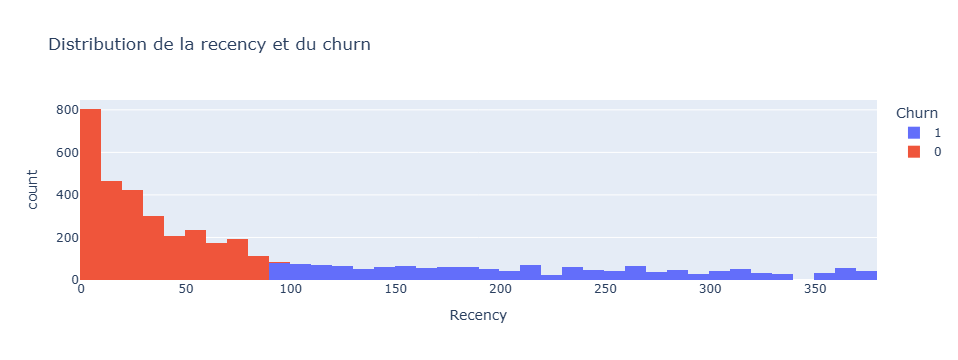

In [81]:
#Distribution du départ d'un client selon la date de ses derniers achats : 1 pour départ 0 pour la conservation du client
fig_churn = px.histogram(
    rfm,
    x="Recency",
    color="Churn",
    title="Distribution de la recency et du churn",
    nbins=50
)
fig_churn.show()


In [82]:
from sklearn.preprocessing import StandardScaler

X = rfm[["Recency", "Frequency", "Monetary"]]

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)


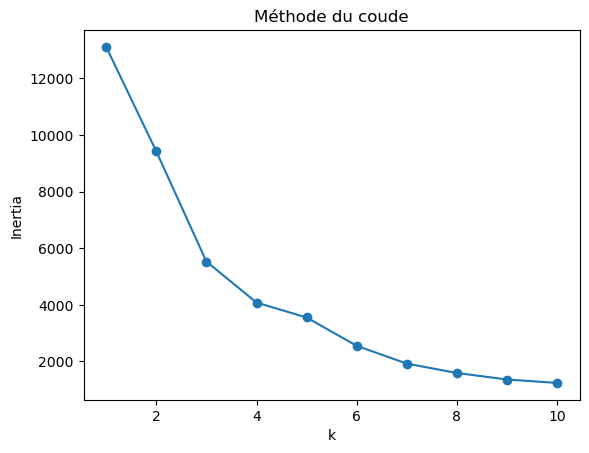

In [83]:
#recherche du bon nombre de clusters
from sklearn.cluster import KMeans
inertias = []
K = range(1, 11)
#On détermine le nombre de clusters k optimal par la méthode du coude
for k in K:
    km = KMeans(n_clusters=k, random_state=42)
    km.fit(X_scaled)
    inertias.append(km.inertia_)

plt.plot(K, inertias, marker='o')
plt.xlabel("k")
plt.ylabel("Inertia")
plt.title("Méthode du coude")
plt.show()


In [84]:
kmeans = KMeans(n_clusters=4, random_state=42)
rfm["Cluster"] = kmeans.fit_predict(X_scaled)


In [85]:
cluster_summary = rfm.groupby("Cluster")[["Recency", "Frequency", "Monetary"]].mean()
cluster_summary


,Recency,Frequency,Monetary
Cluster,,,
0,41.790223,4.371318,1321.409146
1,4.090909,109.727273,124312.306364
2,9.752577,28.510309,12168.264691
3,247.927577,1.805942,455.110716


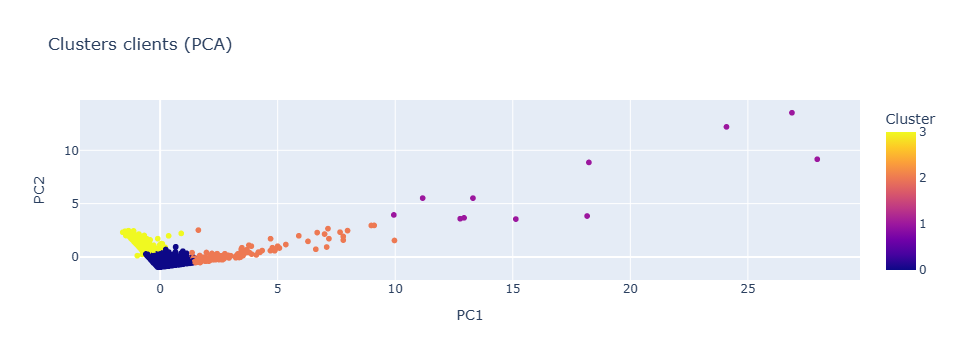

In [87]:
from sklearn.decomposition import PCA
pca = PCA(n_components=2)
coords = pca.fit_transform(X_scaled)
#représentation de la répartition des clients 
rfm["PC1"] = coords[:, 0]
rfm["PC2"] = coords[:, 1]

fig_cluster = px.scatter(
    rfm,
    x="PC1", y="PC2",
    color="Cluster",
    hover_name="CustomerID",
    title="Clusters clients (PCA)"
)

fig_cluster.show()


In [88]:
#analyse de fraudes 

# Factures annulées
factures_annulees = data[data["InvoiceNo"].astype(str).str.startswith("C")]

print("Nombre de factures annulées :", factures_annulees["InvoiceNo"].nunique())
factures_annulees.head()


Nombre de factures annulées : 3836


,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country,Price,Year,Month,Day,Week,DayOfWeek,Hour,MonthName,YearMonth
141,C536379,D,Discount,-1,2010-12-01 09:41:00,27.50,14527.0,United Kingdom,-27.50,2010,12,1,48,Wednesday,9,December,2010-12
154,C536383,35004C,SET OF 3 COLOURED FLYING DUCKS,-1,2010-12-01 09:49:00,4.65,15311.0,United Kingdom,-4.65,2010,12,1,48,Wednesday,9,December,2010-12
235,C536391,22556,PLASTERS IN TIN CIRCUS PARADE,-12,2010-12-01 10:24:00,1.65,17548.0,United Kingdom,-19.80,2010,12,1,48,Wednesday,10,December,2010-12
236,C536391,21984,PACK OF 12 PINK PAISLEY TISSUES,-24,2010-12-01 10:24:00,0.29,17548.0,United Kingdom,-6.96,2010,12,1,48,Wednesday,10,December,2010-12
237,C536391,21983,PACK OF 12 BLUE PAISLEY TISSUES,-24,2010-12-01 10:24:00,0.29,17548.0,United Kingdom,-6.96,2010,12,1,48,Wednesday,10,December,2010-12


In [89]:
# On calcule RFM
rfm = data.groupby("CustomerID").agg({
    "InvoiceDate": lambda x: (data["InvoiceDate"].max() - x.max()).days,
    "InvoiceNo": "nunique",
    "Price": "sum"
}).reset_index()

rfm.columns = ["CustomerID", "Recency", "Frequency", "Monetary"]


In [90]:
#On analyse les outliers : clients dont les métriques sont hors des 3 premiers quartiles
def detect_outliers_IQR(df, col):
    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)
    IQR = Q3 - Q1
    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR
    return df[(df[col] < lower_bound) | (df[col] > upper_bound)], lower_bound, upper_bound

outliers_freq, lb_f, ub_f = detect_outliers_IQR(rfm, "Frequency")
outliers_monetary, _, _ = detect_outliers_IQR(rfm, "Monetary")
outliers_recency, _, _ = detect_outliers_IQR(rfm, "Recency")

print("Clients atypiques (Frequency):", len(outliers_freq))
print("Clients atypiques (Monetary):", len(outliers_monetary))
print("Clients atypiques (Recency):", len(outliers_recency))


Clients atypiques (Frequency): 397
Clients atypiques (Monetary): 423
Clients atypiques (Recency): 149


In [91]:
retours = data[data["Quantity"] < 0]
print("Retours détectés :", len(retours))


Retours détectés : 9288


In [92]:
produits_outliers_qty, lb_q, ub_q = detect_outliers_IQR(data, "Quantity")

print("Produits suspects (quantité anormale) :", produits_outliers_qty.shape[0])
produits_outliers_qty.head()


Produits suspects (quantité anormale) : 57444


,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country,Price,Year,Month,Day,Week,DayOfWeek,Hour,MonthName,YearMonth
9,536367,84879,ASSORTED COLOUR BIRD ORNAMENT,32,2010-12-01 08:34:00,1.69,13047.0,United Kingdom,54.08,2010,12,1,48,Wednesday,8,December,2010-12
26,536370,22728,ALARM CLOCK BAKELIKE PINK,24,2010-12-01 08:45:00,3.75,12583.0,France,90.00,2010,12,1,48,Wednesday,8,December,2010-12
27,536370,22727,ALARM CLOCK BAKELIKE RED,24,2010-12-01 08:45:00,3.75,12583.0,France,90.00,2010,12,1,48,Wednesday,8,December,2010-12
30,536370,21883,STARS GIFT TAPE,24,2010-12-01 08:45:00,0.65,12583.0,France,15.60,2010,12,1,48,Wednesday,8,December,2010-12
31,536370,10002,INFLATABLE POLITICAL GLOBE,48,2010-12-01 08:45:00,0.85,12583.0,France,40.80,2010,12,1,48,Wednesday,8,December,2010-12
